The aim of this notebook is to explore which target shapes can or cannot be learned by a PINned model.

In [2]:
import numpy as np

N = 500
T = 10.5
dt = 0.001
sigma = np.sqrt(0.3)
epsilon = 0.05
neuron_list = [0, 100, 200, 300, 400, 499]

# Inputs generation

In [3]:
from src.inputs_generation import Inputs

WN_tau = 1
h0 = 0.15

ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

# Type 1: Random firing gaussian sequences

In [4]:
from src.targets_generation import Random_firing_gaussian_seq

In [5]:
rfgs = Random_firing_gaussian_seq(T, dt)
targets = rfgs.target_functions(T, sigma, N, epsilon)

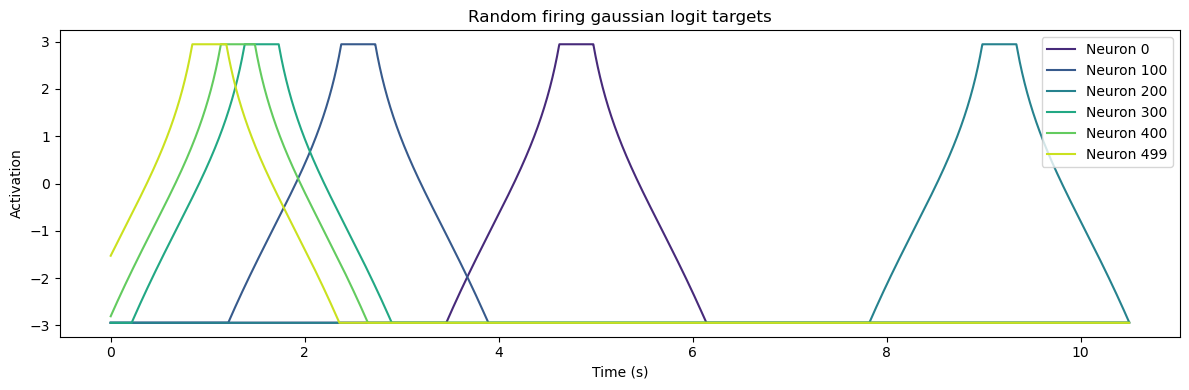

In [6]:
rfgs.target_graph(T, sigma, N, neuron_list, epsilon=epsilon)

In [7]:
# entraînement, simulation, évaluation

In [8]:
from src.training import RNN, PINning

In [9]:
p = 0.08 # fraction of plastic synapses in the network
g = 1.2 # chaos parameter in [1.2, 1.5]
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.0 # error value at which we deem the model to converge
p_reg = 1e-9 # Ridge regularization parameter

Run 1 | run_error=0.026747 | ||J||=313.14 | Δ||J||=+0.00
Run 2 | run_error=0.058618 | ||J||=378.85 | Δ||J||=+65.70
Run 3 | run_error=0.047223 | ||J||=408.11 | Δ||J||=+29.27
Run 4 | run_error=0.040412 | ||J||=426.60 | Δ||J||=+18.48
Run 5 | run_error=0.033308 | ||J||=446.11 | Δ||J||=+19.52
Run 6 | run_error=0.032109 | ||J||=451.93 | Δ||J||=+5.81
Run 7 | run_error=0.037751 | ||J||=467.23 | Δ||J||=+15.30
Run 8 | run_error=0.031645 | ||J||=475.24 | Δ||J||=+8.01
Run 9 | run_error=0.025984 | ||J||=481.63 | Δ||J||=+6.40
Run 10 | run_error=0.024674 | ||J||=486.73 | Δ||J||=+5.10
Run 11 | run_error=0.024264 | ||J||=491.68 | Δ||J||=+4.95
Run 12 | run_error=0.027733 | ||J||=495.96 | Δ||J||=+4.28
Run 13 | run_error=0.027480 | ||J||=500.29 | Δ||J||=+4.32
Run 14 | run_error=0.032566 | ||J||=503.58 | Δ||J||=+3.29
Run 15 | run_error=0.023355 | ||J||=505.55 | Δ||J||=+1.96
Run 16 | run_error=0.024041 | ||J||=507.74 | Δ||J||=+2.19
Run 17 | run_error=0.022307 | ||J||=509.74 | Δ||J||=+2.00
Run 18 | run_error

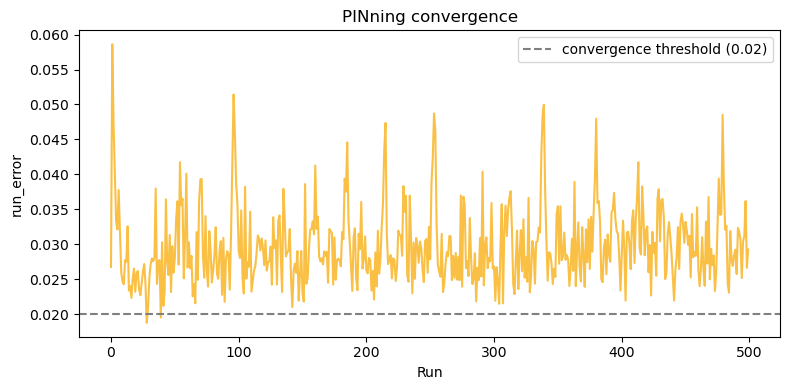

In [10]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

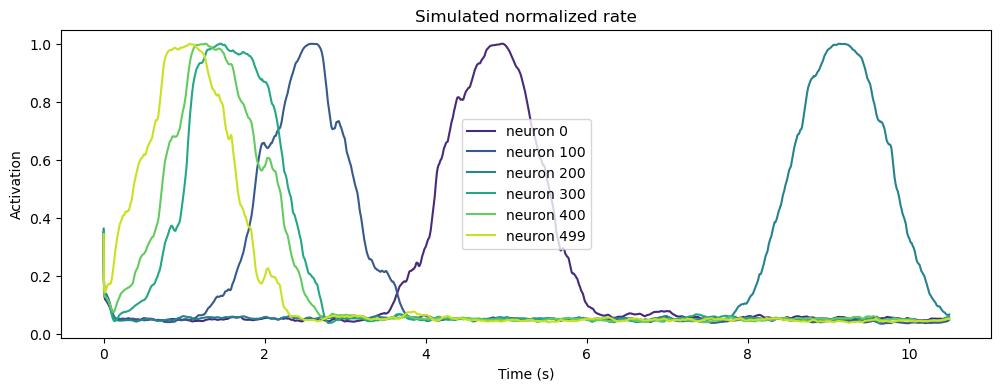

In [11]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

In [12]:
from src.evaluation import Metrics
from scipy.special import expit

threshold = 0.95

targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = rfgs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.718375,0.982671,9
1,Article's metrics for p=0.08,1,0.92,10


# Type 2: Multiple gaussian sequences

In [ ]:
from src.targets_generation import Multiple_gaussian_seq